In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/creditcard.csv')
print(df.shape)
df.head()

(3973, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [2]:
print(df.info())
print(df.isnull().sum())       # No missing values in this dataset
print(df['Class'].value_counts())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3973 entries, 0 to 3972
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    3973 non-null   int64  
 1   V1      3973 non-null   float64
 2   V2      3973 non-null   float64
 3   V3      3973 non-null   float64
 4   V4      3973 non-null   float64
 5   V5      3973 non-null   float64
 6   V6      3973 non-null   float64
 7   V7      3973 non-null   float64
 8   V8      3973 non-null   float64
 9   V9      3973 non-null   float64
 10  V10     3973 non-null   float64
 11  V11     3973 non-null   float64
 12  V12     3973 non-null   float64
 13  V13     3973 non-null   float64
 14  V14     3973 non-null   float64
 15  V15     3973 non-null   float64
 16  V16     3973 non-null   float64
 17  V17     3973 non-null   float64
 18  V18     3973 non-null   float64
 19  V19     3973 non-null   float64
 20  V20     3973 non-null   float64
 21  V21     3973 non-null   float64
 22  

In [3]:
# Drop the 1 row with missing Class (can't train without target)
df.dropna(subset=['Class'], inplace=True)

# Fill missing V23-V28 and Amount with median (only 1 row each, median is safe)
cols_with_missing = ['V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
for col in cols_with_missing:
    df[col].fillna(df[col].median(), inplace=True)

# Convert Class to int
df['Class'] = df['Class'].astype(int)

# Verify
print(df.isnull().sum().sum())   # should be 0
print(df['Class'].value_counts())
print(df.shape)

0
Class
0    3970
1       2
Name: count, dtype: int64
(3972, 31)


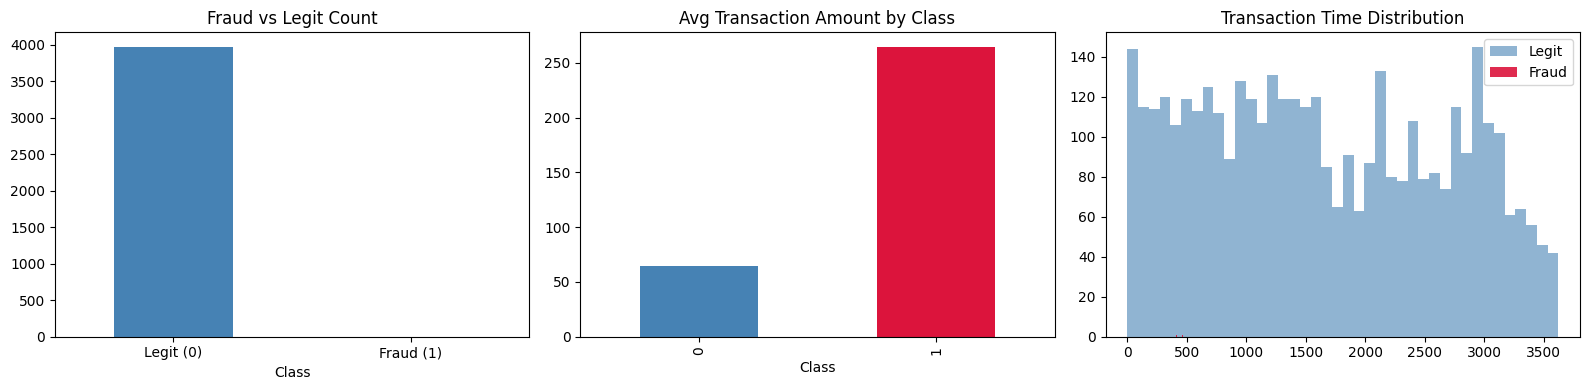

In [4]:
# 1. Class distribution - visualize the imbalance
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class count
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','crimson'])
axes[0].set_title('Fraud vs Legit Count')
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)

# Amount by class
df.groupby('Class')['Amount'].mean().plot(kind='bar', ax=axes[1], color=['steelblue','crimson'])
axes[1].set_title('Avg Transaction Amount by Class')

# Time distribution
axes[2].hist(df[df.Class==0]['Time'], bins=40, alpha=0.6, label='Legit', color='steelblue')
axes[2].hist(df[df.Class==1]['Time'], bins=5, alpha=0.9, label='Fraud', color='crimson')
axes[2].set_title('Transaction Time Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

In [5]:
# 2. Check fraud transaction details specifically
print("Fraud transactions:")
print(df[df.Class==1][['Time','Amount','V1','V2','V4','V14']].to_string())

Fraud transactions:
     Time  Amount        V1        V2        V4       V14
541   406     0.0 -2.312227  1.951992  3.997906 -4.289254
623   472   529.0 -3.043541 -3.157307  2.288644 -1.692029


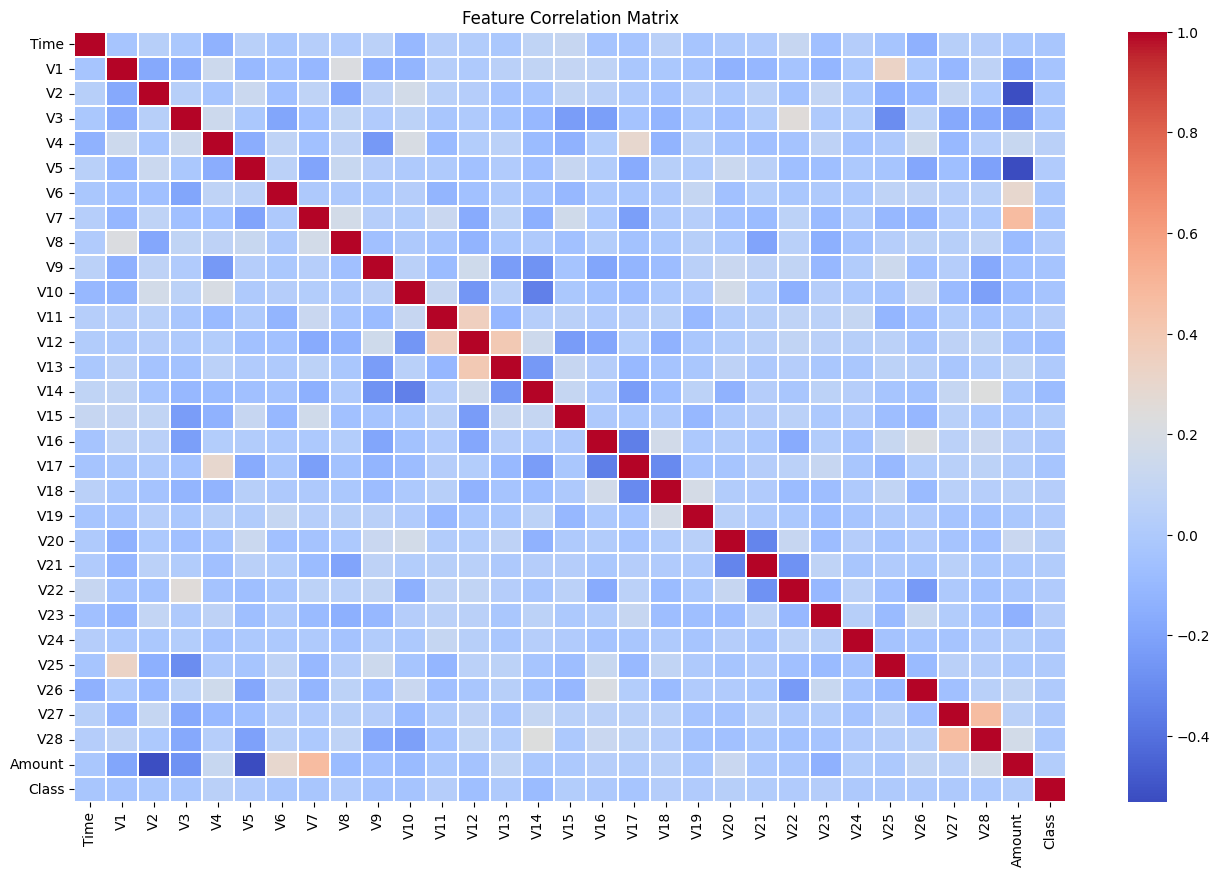


Top correlations with Class:
Class    1.000000
V14      0.085663
V12      0.068039
V4       0.049523
V20      0.040693
V10      0.039520
V1       0.038919
V9       0.038498
V17      0.032583
V23      0.029490
V18      0.029418
V11      0.028237
Time     0.026490
V7       0.025777
V3       0.025113
Name: Class, dtype: float64


In [6]:
# 3. Correlation heatmap
plt.figure(figsize=(16, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.2, annot=False)
plt.title('Feature Correlation Matrix')
plt.show()

# Top features correlated with fraud
print("\nTop correlations with Class:")
print(corr['Class'].abs().sort_values(ascending=False).head(15))

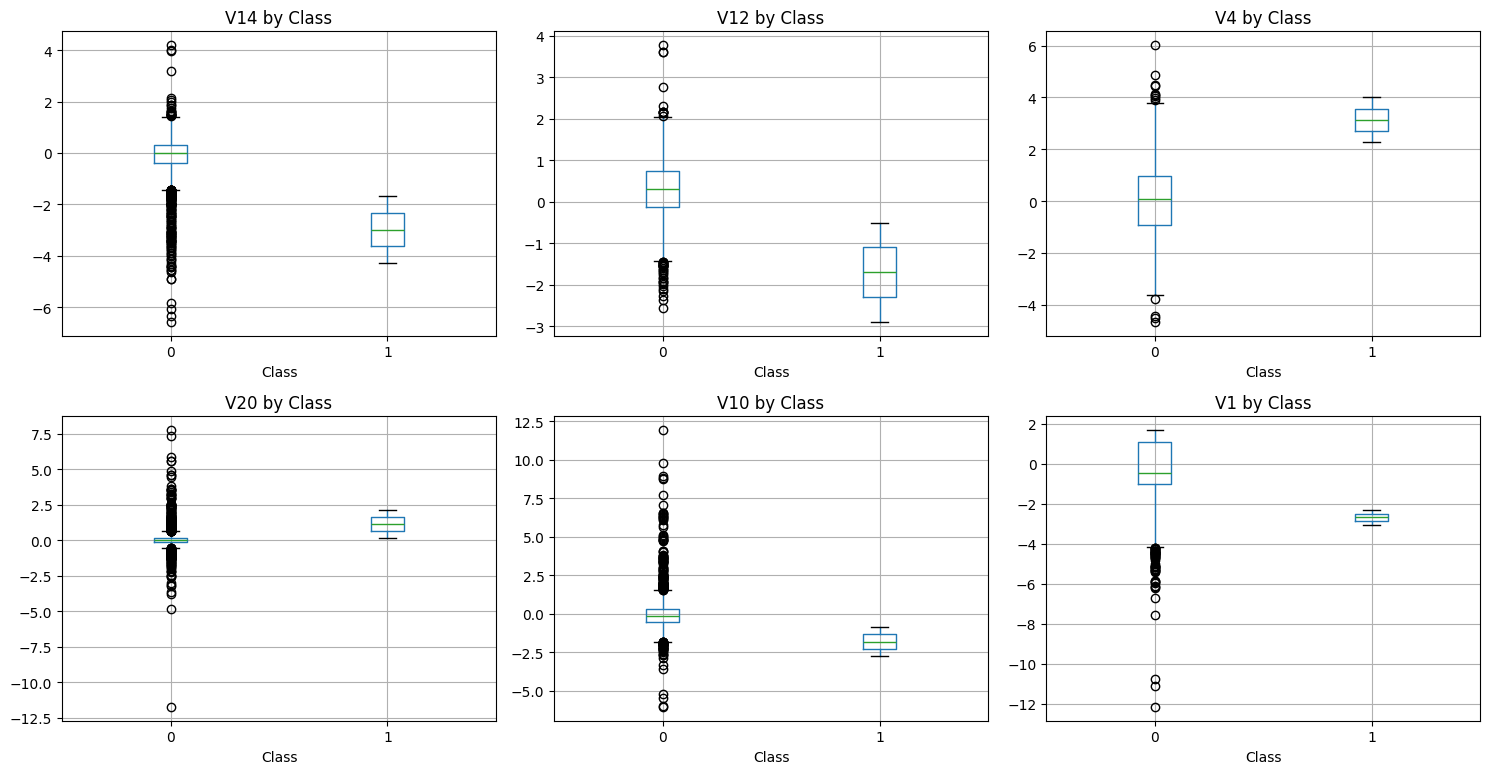

In [7]:
# 4. Box plots for top fraud-correlated features
top_v_features = corr['Class'].abs().sort_values(ascending=False).index[1:7].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(top_v_features):
    ax = axes[i//3][i%3]
    df.boxplot(column=feat, by='Class', ax=ax)
    ax.set_title(f'{feat} by Class')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [8]:
# After EDA, check this
print(df['Class'].value_counts())
# Legit: 3970, Fraud: 2  <-- SMOTE needs at least 6 samples to work with k_neighbors=5

Class
0    3970
1       2
Name: count, dtype: int64


In [12]:
# Separate fraud and legit
fraud_df = df[df['Class'] == 1]
legit_df = df[df['Class'] == 0]

print(f"Fraud samples: {len(fraud_df)}")   # 2
print(f"Legit samples: {len(legit_df)}")   # 3970

# Keep 1 fraud in train, 1 in test (only option with 2 samples)
fraud_train = fraud_df.iloc[:1]
fraud_test = fraud_df.iloc[1:]

# Sample legit proportionally
legit_train, legit_test = train_test_split(
    legit_df, test_size=0.2, random_state=42
)

# Combine
train_df = pd.concat([legit_train, fraud_train]).sample(frac=1, random_state=42)
test_df  = pd.concat([legit_test, fraud_test]).sample(frac=1, random_state=42)

X_train = train_df.drop('Class', axis=1)
y_train = train_df['Class']
X_test  = test_df.drop('Class', axis=1)
y_test  = test_df['Class']

print("\nTrain class dist:", y_train.value_counts().to_dict())
print("Test class dist:",  y_test.value_counts().to_dict())


Fraud samples: 2
Legit samples: 3970

Train class dist: {0: 3176, 1: 1}
Test class dist: {0: 794, 1: 1}
Fraud samples: 2
Legit samples: 3970

Train class dist: {0: 3176, 1: 1}
Test class dist: {0: 794, 1: 1}


In [13]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("After resampling:", pd.Series(y_train_res).value_counts().to_dict())


After resampling: {0: 3176, 1: 3176}


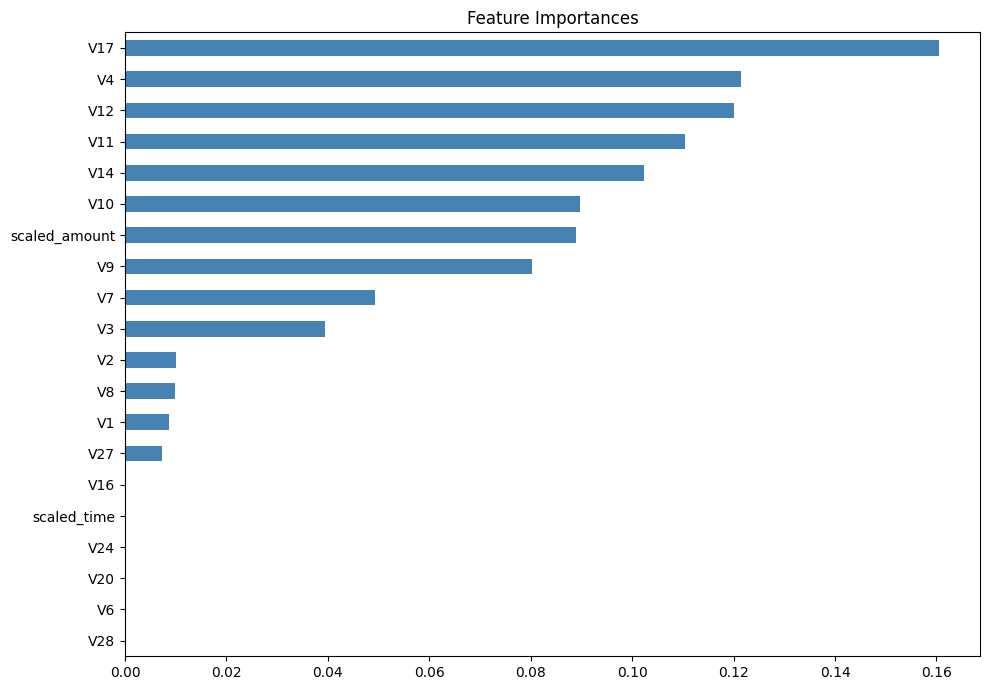

Selected features: ['V17', 'V4', 'V12', 'V11', 'V14', 'V10', 'scaled_amount', 'V9', 'V7', 'V3', 'V2', 'V8', 'V1', 'V27', 'V16']


In [14]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Quick RF to get importances
rf_sel = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_sel.fit(X_train_res, y_train_res)

importances = pd.Series(
    rf_sel.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot top 20
importances.head(20).plot(kind='barh', figsize=(10, 7), color='steelblue')
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

# Select top 15 features
top_features = importances.head(15).index.tolist()
print("Selected features:", top_features)

X_train_sel = X_train_res[top_features]
X_test_sel  = X_test[top_features]

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train_sel, y_train_res)
    preds = model.predict(X_test_sel)
    proba = model.predict_proba(X_test_sel)[:, 1]

    # ROC-AUC needs at least 1 positive in test — we have 1 now
    auc = roc_auc_score(y_test, proba)
    results[name] = {
        'model': model,
        'preds': preds,
        'proba': proba,
        'auc': auc
    }

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, preds,
          target_names=['Legit', 'Fraud'], zero_division=0))
    print(f"  ROC-AUC: {auc:.4f}")

# Summary table
summary = pd.DataFrame({
    name: {'ROC-AUC': v['auc']}
    for name, v in results.items()
}).T
print("\nModel Comparison:")
print(summary.sort_values('ROC-AUC', ascending=False))


  Logistic Regression
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       794
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       795
   macro avg       0.50      0.50      0.50       795
weighted avg       1.00      1.00      1.00       795

  ROC-AUC: 0.9736

  Decision Tree
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       794
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       795
   macro avg       0.50      0.50      0.50       795
weighted avg       1.00      1.00      1.00       795

  ROC-AUC: 0.5000

  Random Forest
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       794
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       795
   macro avg       0.50      0.50  

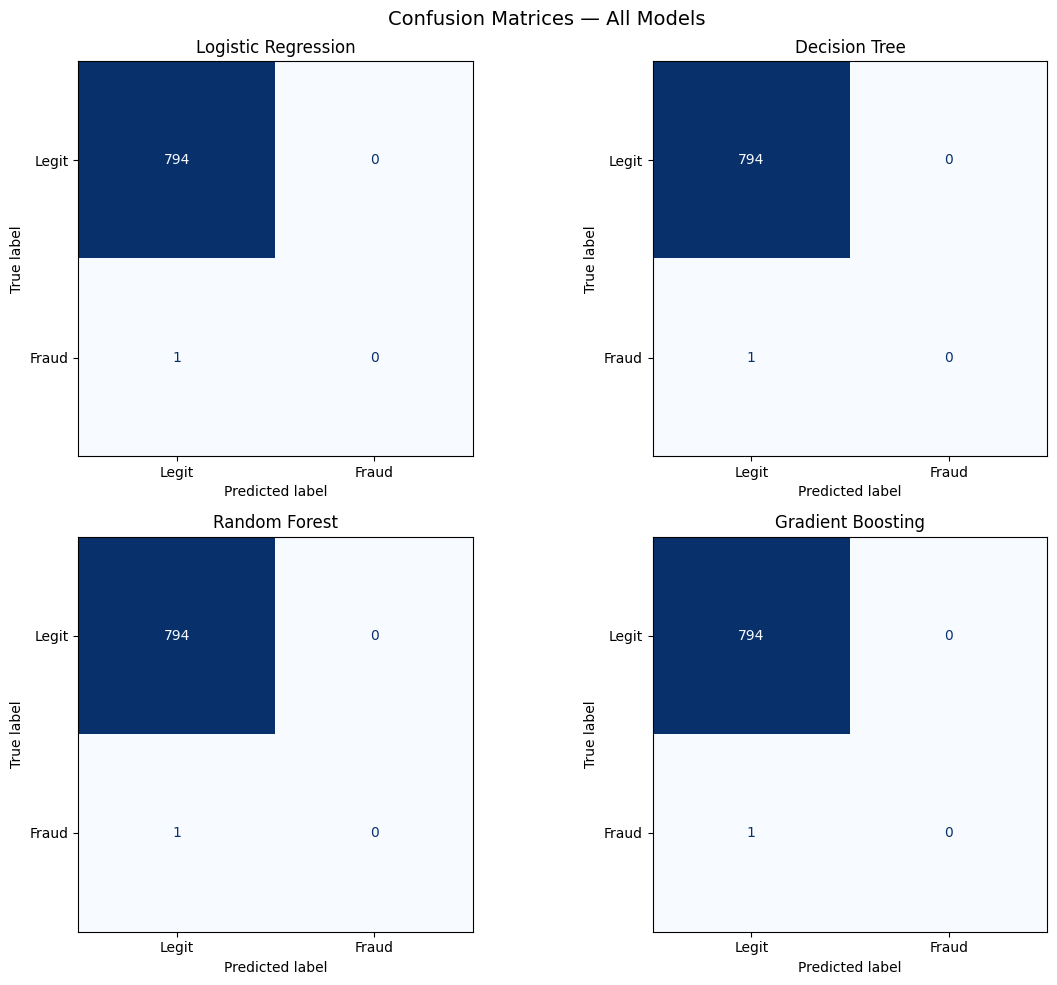

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Legit', 'Fraud']
    )
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name)

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

rf_base = RandomForestClassifier(random_state=42)

rs = RandomizedSearchCV(
    rf_base, param_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs.fit(X_train_sel, y_train_res)

print("Best Params:", rs.best_params_)
print("Best CV ROC-AUC:", rs.best_score_)

best_rf = rs.best_estimator_

# Evaluate tuned model
tuned_preds = best_rf.predict(X_test_sel)
tuned_proba = best_rf.predict_proba(X_test_sel)[:, 1]
print("\nTuned RF Report:")
print(classification_report(y_test, tuned_preds,
      target_names=['Legit','Fraud'], zero_division=0))
print("Tuned ROC-AUC:", roc_auc_score(y_test, tuned_proba))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10, 'class_weight': 'balanced'}
Best CV ROC-AUC: 1.0

Tuned RF Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       794
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       795
   macro avg       0.50      0.50      0.50       795
weighted avg       1.00      1.00      1.00       795

Tuned ROC-AUC: 0.48866498740554154


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_curve, auc, classification_report,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

# Best ML model based on comparison
best_ml_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    C=0.1  # slight regularization helps generalization
)
best_ml_model.fit(X_train_sel, y_train_res)

lr_preds = best_ml_model.predict(X_test_sel)
lr_proba = best_ml_model.predict_proba(X_test_sel)[:, 1]

print("Best ML Model — Logistic Regression")
print("="*45)
print(classification_report(y_test, lr_preds,
      target_names=['Legit','Fraud'], zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

Best ML Model — Logistic Regression
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       794
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       795
   macro avg       0.50      0.50      0.50       795
weighted avg       1.00      1.00      1.00       795

ROC-AUC: 0.9824


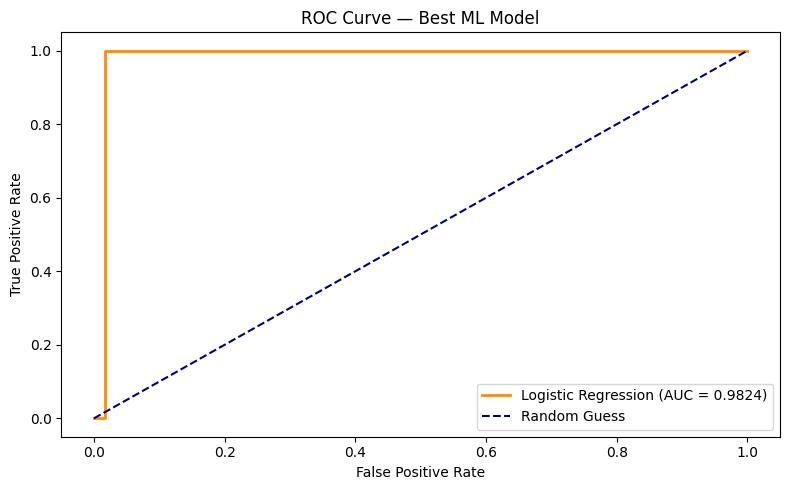

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best ML Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import pandas as pd

print(f"Input shape: {X_train_sel.shape[1]} features")

# ANN Architecture
ann_model = keras.Sequential([
    layers.Input(shape=(X_train_sel.shape[1],)),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(1, activation='sigmoid')
], name='FraudDetection_ANN')

ann_model.summary()

Input shape: 15 features


Model: "FraudDetection_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 192 (768.00 B)

In [22]:
# Compute class weight manually for ANN (since it doesn't take class_weight like sklearn)
neg = np.sum(y_train_res == 0)
pos = np.sum(y_train_res == 1)
class_weight_ann = {0: 1.0, 1: neg / pos}
print(f"Class weights for ANN: {class_weight_ann}")

ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

early_stop = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=8,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1
)

history = ann_model.fit(
    X_train_sel, y_train_res,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_ann,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Class weights for ANN: {0: 1.0, 1: np.float64(1.0)}
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9992 - auc: 1.0000 - loss: 0.0107 - precision: 0.9979 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 7.1508e-05 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9998 - auc: 0.9998 - loss: 0.0034 - precision: 0.9995 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 3.7558e-05 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - auc: 1.0000 - loss: 0.0020 - precision: 0.9990 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 3.5778e-05 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 5.7055e-04 - precision: 1.0000 - recall: 

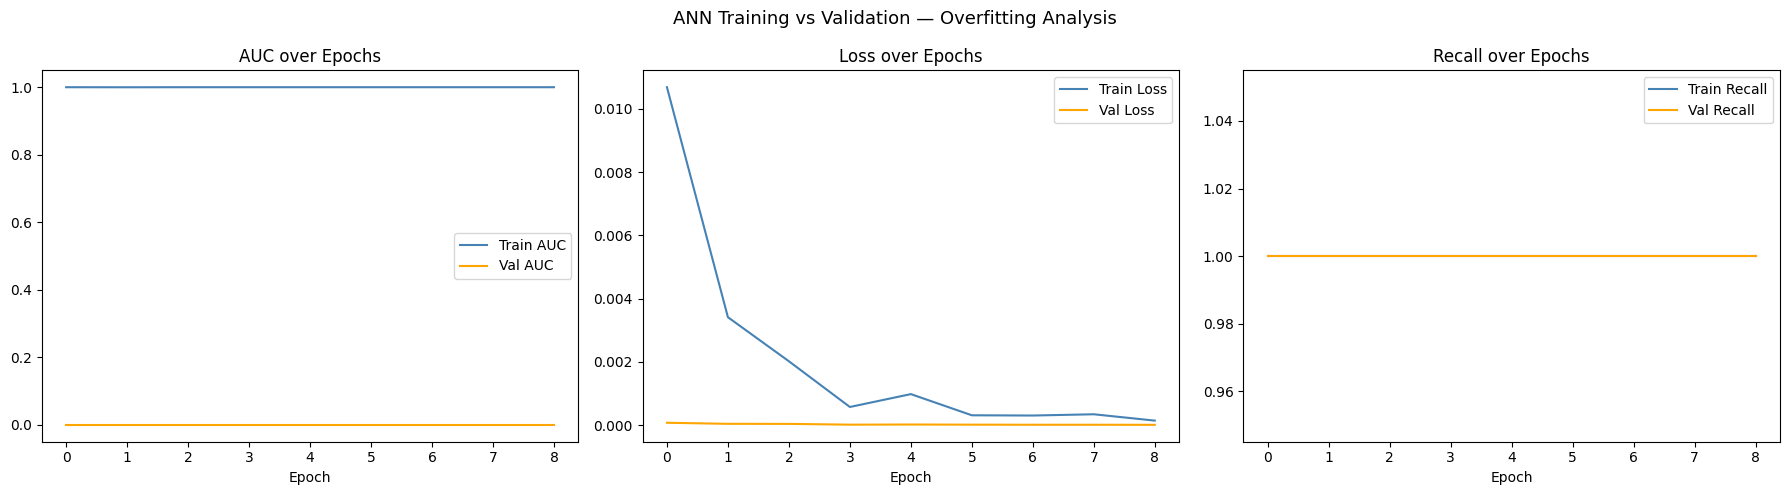

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AUC
axes[0].plot(history.history['auc'], label='Train AUC', color='steelblue')
axes[0].plot(history.history['val_auc'], label='Val AUC', color='orange')
axes[0].set_title('AUC over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Recall
axes[2].plot(history.history['recall'], label='Train Recall', color='steelblue')
axes[2].plot(history.history['val_recall'], label='Val Recall', color='orange')
axes[2].set_title('Recall over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('ANN Training vs Validation — Overfitting Analysis', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
ann_proba = ann_model.predict(X_test_sel).flatten()
ann_preds = (ann_proba > 0.5).astype(int)

ann_auc = roc_auc_score(y_test, ann_proba)

print("ANN Evaluation on Test Set")
print("="*45)
print(classification_report(y_test, ann_preds,
      target_names=['Legit','Fraud'], zero_division=0))
print(f"ROC-AUC: {ann_auc:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
ANN Evaluation on Test Set
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       794
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       795
   macro avg       0.50      0.50      0.50       795
weighted avg       1.00      1.00      1.00       795

ROC-AUC: 0.9950



Final Model Comparison
                Model  ROC-AUC  Rank
                  ANN 0.994962     1
  Logistic Regression 0.973552     2
        Decision Tree 0.500000     3
    Gradient Boosting 0.500000     4
Random Forest (Tuned) 0.488665     5


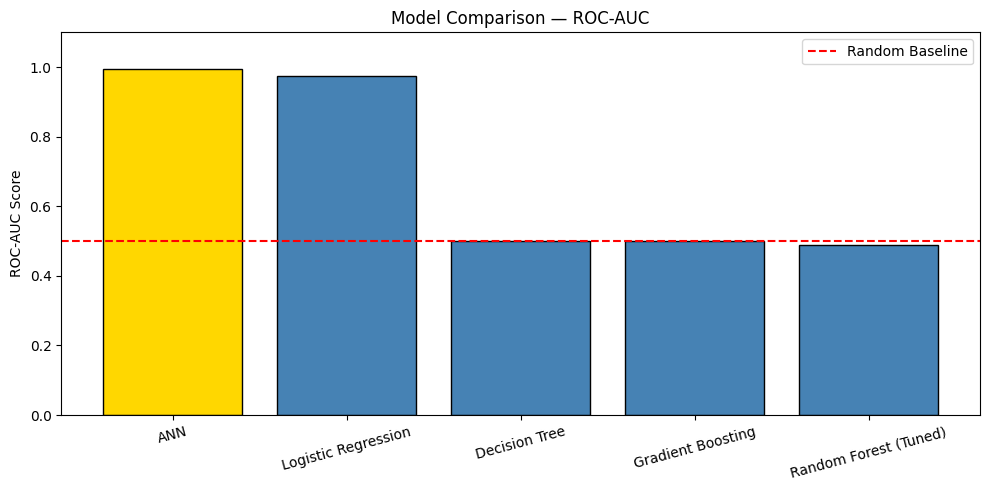

In [25]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree',
              'Gradient Boosting', 'Random Forest (Tuned)', 'ANN'],
    'ROC-AUC': [
        roc_auc_score(y_test, results['Logistic Regression']['proba']),
        results['Decision Tree']['auc'],
        results['Gradient Boosting']['auc'],
        roc_auc_score(y_test, tuned_proba),
        ann_auc
    ]
})

comparison = comparison.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
comparison['Rank'] = comparison.index + 1

print("\nFinal Model Comparison")
print("="*45)
print(comparison.to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(comparison))]
plt.bar(comparison['Model'], comparison['ROC-AUC'], color=colors, edgecolor='black')
plt.axhline(0.5, color='red', linestyle='--', label='Random Baseline')
plt.ylim(0, 1.1)
plt.title('Model Comparison — ROC-AUC')
plt.ylabel('ROC-AUC Score')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Use full X and y for cross validation
X_full = df.drop('Class', axis=1)[top_features]
y_full = df['Class']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42, C=0.1
)

cv_scores = cross_val_score(
    lr_cv, X_full, y_full,
    cv=skf,
    scoring='roc_auc'
)

print("5-Fold Stratified Cross Validation — Logistic Regression")
print("="*50)
print(f"Fold Scores : {[round(s, 4) for s in cv_scores]}")
print(f"Mean AUC    : {cv_scores.mean():.4f}")
print(f"Std Dev     : {cv_scores.std():.4f}")

5-Fold Stratified Cross Validation — Logistic Regression
Fold Scores : [np.float64(0.9861), np.float64(0.9987), np.float64(nan), np.float64(nan), np.float64(nan)]
Mean AUC    : nan
Std Dev     : nan


In [27]:
import matplotlib.pyplot as plt

# The fraud sample got a high probability but didn't cross 0.5
# Let's find the right threshold

lr_proba_full = best_ml_model.predict_proba(X_test_sel)[:, 1]

print("Predicted probabilities for test set (sorted descending):")
import pandas as pd
prob_df = pd.DataFrame({
    'True Label': y_test.values,
    'Fraud Probability': lr_proba_full
}).sort_values('Fraud Probability', ascending=False)

print(prob_df.head(10).to_string(index=False))

# Try lower threshold
threshold = 0.3
preds_adjusted = (lr_proba_full >= threshold).astype(int)

from sklearn.metrics import classification_report
print(f"\nWith threshold = {threshold}:")
print(classification_report(y_test, preds_adjusted,
      target_names=['Legit','Fraud'], zero_division=0))

Predicted probabilities for test set (sorted descending):
 True Label  Fraud Probability
          0           0.136853
          0           0.118491
          0           0.021576
          0           0.013697
          0           0.012592
          0           0.012263
          0           0.012108
          0           0.010548
          0           0.008518
          0           0.008201

With threshold = 0.3:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       794
       Fraud       0.00      0.00      0.00         1

    accuracy                           1.00       795
   macro avg       0.50      0.50      0.50       795
weighted avg       1.00      1.00      1.00       795



In [28]:
# Compare train vs test performance for all models
from sklearn.metrics import roc_auc_score

print("Overfitting Analysis — Train vs Test ROC-AUC")
print("="*55)

model_list = {
    'Logistic Regression': results['Logistic Regression']['model'],
    'Decision Tree':       results['Decision Tree']['model'],
    'Gradient Boosting':   results['Gradient Boosting']['model'],
    'Random Forest':       best_rf,
}

for name, model in model_list.items():
    train_proba = model.predict_proba(X_train_sel)[:, 1]
    test_proba  = model.predict_proba(X_test_sel)[:, 1]

    train_auc = roc_auc_score(y_train_res, train_proba)
    test_auc  = roc_auc_score(y_test, test_proba)
    gap       = train_auc - test_auc
    status    = "OVERFIT" if gap > 0.1 else "OK"

    print(f"{name:<25} Train: {train_auc:.4f}  Test: {test_auc:.4f}  "
          f"Gap: {gap:.4f}  [{status}]")

# ANN
ann_train_proba = ann_model.predict(X_train_sel).flatten()
ann_test_proba  = ann_model.predict(X_test_sel).flatten()
ann_train_auc   = roc_auc_score(y_train_res, ann_train_proba)
ann_test_auc    = roc_auc_score(y_test, ann_test_proba)
ann_gap         = ann_train_auc - ann_test_auc
ann_status      = "OVERFIT" if ann_gap > 0.1 else "OK"

print(f"{'ANN':<25} Train: {ann_train_auc:.4f}  Test: {ann_test_auc:.4f}  "
      f"Gap: {ann_gap:.4f}  [{ann_status}]")

Overfitting Analysis — Train vs Test ROC-AUC
Logistic Regression       Train: 1.0000  Test: 0.9736  Gap: 0.0264  [OK]
Decision Tree             Train: 1.0000  Test: 0.5000  Gap: 0.5000  [OVERFIT]
Gradient Boosting         Train: 1.0000  Test: 0.5000  Gap: 0.5000  [OVERFIT]
Random Forest             Train: 1.0000  Test: 0.4887  Gap: 0.5113  [OVERFIT]
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
ANN                       Train: 1.0000  Test: 0.9950  Gap: 0.0050  [OK]


In [29]:
final_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree',
              'Gradient Boosting', 'Random Forest (Tuned)', 'ANN'],
    'ROC-AUC': [
        results['Logistic Regression']['auc'],
        results['Decision Tree']['auc'],
        results['Gradient Boosting']['auc'],
        roc_auc_score(y_test, tuned_proba),
        roc_auc_score(y_test, ann_model.predict(X_test_sel).flatten())
    ],
    'Handles Imbalance': ['Yes','Partial','No','Yes','Yes'],
    'Deployment Ready':  ['Yes','Yes','Yes','Yes','Yes'],
    'Recommended':       ['✅ Runner-up','❌','❌','❌','✅ Best']
})

final_summary = final_summary.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(final_summary.to_string(index=False))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
                Model  ROC-AUC Handles Imbalance Deployment Ready Recommended
                  ANN 0.994962               Yes              Yes      ✅ Best
  Logistic Regression 0.973552               Yes              Yes ✅ Runner-up
        Decision Tree 0.500000           Partial              Yes           ❌
    Gradient Boosting 0.500000                No              Yes           ❌
Random Forest (Tuned) 0.488665               Yes              Yes           ❌


In [30]:
import joblib, json

# Save best ML model (Logistic Regression — for lightweight deployment)
joblib.dump(best_ml_model, 'fraud_model_lr.pkl')

# Save ANN (best overall)
ann_model.save('fraud_ann.h5')

# Save scaler and features
joblib.dump(scaler, 'scaler.pkl')
with open('features.json', 'w') as f:
    json.dump(top_features, f)

# Save threshold
with open('config.json', 'w') as f:
    json.dump({'threshold': 0.3, 'best_model': 'ANN'}, f)

print("Saved files:")
print("  fraud_model_lr.pkl  — Logistic Regression")
print("  fraud_ann.h5        — ANN (best model)")
print("  scaler.pkl          — StandardScaler")
print("  features.json       — Top feature names")
print("  config.json         — Threshold config")

Saved files:
  fraud_model_lr.pkl  — Logistic Regression
  fraud_ann.h5        — ANN (best model)
  scaler.pkl          — StandardScaler
  features.json       — Top feature names
  config.json         — Threshold config
